# Heavy ion jet quenching with ***ATLAS*** Open Data
### Data
Based on arXiv:1011.6182v2

In [138]:
# File reading
import uproot
# Analysis
import awkward as ak
import numpy as np
# Plotting
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})

# Constants
GeV = 1e-3
TeV = 1e-6

In [139]:
# - Useful plotting functions - #
# Use innerward facing ticks in all direction
def inner_ticks(ax:matplotlib.axes.Axes):
    ax.tick_params(direction="in",which="both",top=True,right=True)

# Plot an ATLAS Open Data label on a pair of axes
def atlas_label(ax:matplotlib.axes.Axes,loc="upper right",text="Open Data",fontsize=16,pos_ovr=None,msg=""):
    locs = {
        "upper left" : (.04, .88),
        "upper right": (.96, .88),
    }
    if (pos_ovr is not None) and isinstance(pos_ovr,tuple):
        pos = pos_ovr 
    else: pos = locs[loc]
    align = ("left","right","center"); ha = "left"
    for a in align:
        if a in loc: ha = a
    ax.text(
        *pos,r"$\mathbfit{ATLAS}$ "+text,
        transform=ax.transAxes,fontsize=fontsize,ha=ha,va="bottom"
    )
    if msg:
        ax.text(
            pos[0], pos[1]-.05, msg,
            transform=ax.transAxes, fontsize=fontsize*.75, ha=ha, va="bottom"
        )

In [140]:
# Cutting functions
def cut_n_jets(jets:ak.Array,N=2)->ak.Array:
    return jets[ak.num(jets) >= N]

def cut_pt(jets:ak.Array,leading=100,subleading=25)->ak.Array:
    jets = jets[ak.argsort(jets["pt"],axis=1,ascending=False)]
    leading_mask = jets["pt"][:,0]*GeV > leading #GeV
    subleading_mask = jets["pt"][:,1]*GeV > subleading
    return jets[leading_mask & subleading_mask]

def cut_et(jets:ak.Array,leading=100,subleading=25)->ak.Array:
    jets["et"] = np.sqrt(jets["pt"]*jets["pt"] + jets["m"]*jets["m"])
    jets = jets[ak.argsort(jets["et"],axis=1,ascending=False)]
    leading_mask = jets["et"][:,0]*GeV > leading
    subleading_mask = jets["et"][:,1]*GeV > subleading
    return jets[leading_mask & subleading_mask]

def cut_eta(jets:ak.Array,eta=2.8):
    return jets[np.abs(jets["eta"][:,0]) < eta]

def cut_opp_hemispheres(jets:ak.Array)->ak.Array:
    return jets[np.abs(jets["phi"][:,1] - jets["phi"][:,0]) > np.pi*.5]

# Book keeping
cutflow = {
    "event": {},
    "track": {}
}

# Get the number of entries in a jagged awkward array
def get_entries(array:ak.Array):
    return ak.sum(ak.num(array))

# Function to update cutflow dictionary after applying a cut to jets
def update_cutflow(cut:str,jets:ak.Array,cutflow=cutflow):
    cutflow["event"][cut], cutflow["track"][cut] = len(jets), get_entries(jets)

In [141]:
# Calculate dijet asymmetry factor A_J
def calculate_aj(jets:ak.Array):
    AJ = (jets["et"][:,0]-jets["et"][:,1])/(jets["et"][:,0]+jets["et"][:,1])
    return AJ

In [142]:
# Group event numbers by centrality
def group_by_centrality(fcal:ak.Array)->dict:
    centrality_ranges = {
        "(40 - 100)%": {
            "upper": 0.9, # TeV
            "lower": 0. # TeV
        },
        "(20 - 40)%": {
            "upper": 2.1,
            "lower": 0.9
        },
        "(10 - 20)%": {
            "upper": 3,
            "lower": 2.1
        },
        "(0 - 10)%": {
            "upper":9e9,
            "lower": 3
        }
    }

    fcal["TotalEt"] = fcal["FCalEtA"] + fcal["FCalEtC"]
    for range in centrality_ranges:
        upper, lower = centrality_ranges[range]["upper"], centrality_ranges[range]["lower"]
        upper_mask, lower_mask = fcal["TotalEt"]*TeV < upper, fcal["TotalEt"]*TeV >= lower
        centrality_ranges[range]["event_numbers"] = fcal[upper_mask & lower_mask]["eventNumber"]
    
    return centrality_ranges

In [143]:
# Load from local file
with uproot.open("DAOD_HIONHPOD_DATA.output.pool.root:CollectionTree") as tree:
    # Fill array with jet kinematics
    # Branches are renamed from full branch names to e.g. "pt"
    jets = ak.zip({
        branch.split("_")[1]: tree[branch].array() for branch in (
            "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_pt",
            "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_eta",
            "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_phi",
            "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_m"
        )
    } | {
        "eventNumber": tree["EventInfoAuxDyn.eventNumber"].array()
    })

    # Fill FCal transverse energies and similarly reformat branch names
    fcal = ak.zip({
        branch.split(".")[1]: tree[branch].array() for branch in (
            f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
        )
    } | {
        "eventNumber": tree["EventInfoAuxDyn.eventNumber"].array()
    })
update_cutflow("initial",jets)

In [144]:
jets = cut_n_jets(jets); update_cutflow("N_jets",jets)
jets = cut_et(jets); update_cutflow("et",jets)
jets = cut_eta(jets); update_cutflow("eta",jets)
jets = cut_opp_hemispheres(jets); update_cutflow("hemispheres",jets)
print(cutflow)

{'event': {'initial': 1711, 'N_jets': 1679, 'et': 1336, 'eta': 1211, 'hemispheres': 692}, 'track': {'initial': np.int64(25049), 'N_jets': np.int64(25033), 'et': np.int64(22331), 'eta': np.int64(20133), 'hemispheres': np.int64(11420)}}


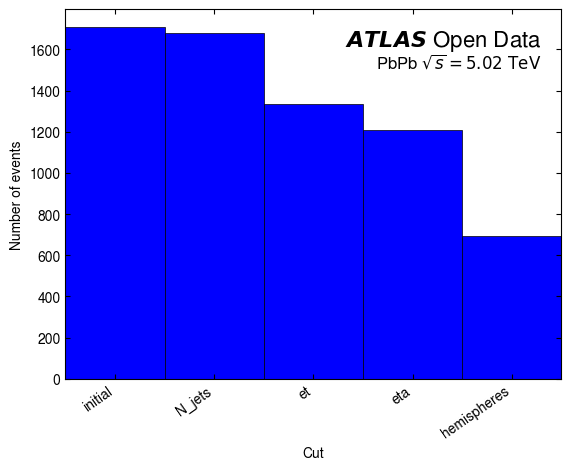

In [145]:
# Plot a cutflow bar chart
xlabels = [scope for scope in cutflow["event"]]
cuts = [cutflow["event"][scope] for scope in xlabels]
cutflow_fig, cutflow_ax = plt.subplots()
cutflow_ax.bar(xlabels,cuts,width=1.,linewidth=.5,edgecolor="k",color="blue")
cutflow_ax.set_xticks(xlabels); cutflow_ax.set_xticklabels(xlabels, rotation=35, ha="right")
inner_ticks(cutflow_ax)
cutflow_ax.margins(x=0)
cutflow_ax.set_ylabel("Number of events"); _ = cutflow_ax.set_xlabel("Cut")
atlas_label(cutflow_ax,msg=r"PbPb $\sqrt{s}=5.02\ \mathrm{TeV}$")

In [146]:
centralities = group_by_centrality(fcal)
jet_eventNumbers = jets["eventNumber"][:,0]
central_jets = jets[np.isin(jet_eventNumbers,centralities["(0 - 10)%"]["event_numbers"])]
peripheral_jets = jets[np.isin(jet_eventNumbers,centralities["(10 - 20)%"]["event_numbers"])]
print(central_jets["pt"])

[[1.61e+05, 1.57e+05, 1.53e+05, ..., 7.38e+04, 6.93e+04, 6.13e+04], ..., [...]]


[0.0137, 0.0285, 0.0716, 0.00466, 0.00926, ..., 0.0116, 0.0126, 0.0195, 0.0185]
[0.00709, 0.00781, 0.046, 0.0349, 0.0363, ..., 0.0182, 0.0538, 0.0132, 0.0517]


(array([56., 66., 38., 26., 25., 15., 11.,  8.,  8.,  4.]),
 array([0.00017596, 0.01070703, 0.0212381 , 0.03176917, 0.04230024,
        0.05283131, 0.06336237, 0.07389345, 0.08442452, 0.09495559,
        0.10548666]),
 <BarContainer object of 10 artists>)

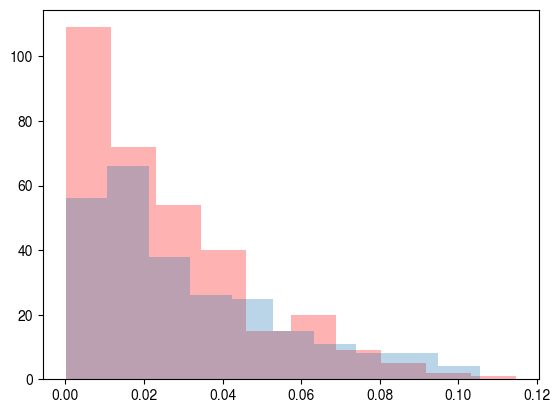

In [147]:
central_AJ = calculate_aj(central_jets)
peripheral_AJ = calculate_aj(peripheral_jets)
print(central_AJ)
print(peripheral_AJ)

fig, ax = plt.subplots()
ax.hist(central_AJ,density=False,alpha=.3,color="red")
ax.hist(peripheral_AJ,density=False,alpha=.3)